In [118]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [136]:
%matplotlib notebook

In [160]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803121\2025-11-05_803121\803121_2025-11-05_11-16-57_slap2_2025-11-25_23-16-22\source_extraction\ExperimentSummary\SummaryLoCo-260202-141133.mat"

In [104]:
f = h5py.File(datapath, "r")
E = f["exptSummary"]["E"]
print("E shape:", E.shape, "dtype:", E.dtype)

E shape: (2, 62) dtype: object


In [105]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import h5py

# This should exist in your repo per the new structure you made.
# If your bytes_to_str is elsewhere, update this import accordingly.
from vip_slap2_analysis.io.matv73 import MatV73File, bytes_to_str


ChannelSpec = Union[None, int, str, Sequence[Union[int, str]]]


def _as_1d_bool(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x).astype(bool).squeeze()
    if x.ndim != 1:
        x = x.reshape(-1)
    return x


def _align_bool_mask(mask: np.ndarray, n: int) -> np.ndarray:
    """Ensure mask is 1D length n. Truncate if longer; pad False if shorter."""
    mask = _as_1d_bool(mask)
    if mask.size == n:
        return mask
    if mask.size > n:
        return mask[:n]
    out = np.zeros(n, dtype=bool)
    out[: mask.size] = mask
    return out


@dataclass
class GlutamateSummary:
    """
    Fast, lazy loader for summarize_LoCo.m ExperimentSummary files.

    Expected on-disk layout (MATLAB -v7.3 / HDF5):
      - top-level group: exptSummary
      - exptSummary/E: ref-typed dataset (MATLAB cell array) indexing trial groups
      - per-trial group contains trace groups like:
          dF/ls, dF/matchFilt, dF/denoised, dF/nonneg, dF/events
          dFF/<...> (sometimes)
          F0 (sometimes)
          frameLines (often)
          ROIs/F, ROIs/Fsvd (user ROI traces; often)
          footprints (sometimes dense; sometimes sparse, LoCo style)
      - summary images:
          exptSummary/meanIM{dmd}, exptSummary/actIM{dmd} via ref-cells

    Multimodal recordings:
      - numChannels is typically 1 (green only) or 2 (green+red)
      - This class returns traces as (samples, rois, channels) by default.
    """

    file_path: Union[str, Path]
    keep_open: bool = True
    swap_xy_images: bool = True
    cache_e_groups: bool = True
    max_group_cache: int = 64  # simple LRU-ish cap

    def __post_init__(self) -> None:
        self.file_path = Path(self.file_path)
        self._mat = MatV73File(self.file_path, keep_open=self.keep_open)
    
        if "exptSummary" not in self._mat.f:
            raise KeyError(
                f"Top-level variable 'exptSummary' not found. Keys: {list(self._mat.f.keys())}"
            )

        self.n_trials: int = 0
        self.n_dmds: int = 0
        self.keep_trials: np.ndarray
        self.valid_trials: List[List[int]] = []
        self.trials_to_analyze: List[int] = []
        self.n_synapses: List[int] = []
        self.n_channels: int = 1
        self.dmd_zs: np.ndarray = np.array([np.nan, np.nan], dtype=float)

        self._E_layout: str = "dmd_trial"  # or "trial_dmd"
        self._e_cache: Dict[Tuple[int, int], h5py.Group] = {}
        self._e_cache_order: List[Tuple[int, int]] = []

        self._get_info()
        self._metadata = None  # lazy
        self._align_params = None  # lazy
        self._trial_n_channels: Dict[Tuple[int,int], int] = {}

    # ----------------- lifecycle -----------------

    def close(self) -> None:
        self._mat.close()

    # ----------------- structure inference -----------------
    def _infer_trial_n_channels(self, g: h5py.Group) -> int:
        """
        Infer number of recorded channels for a given E trial group.

        Priority:
          1) If params.numChannels exists, use it.
          2) Otherwise infer from a trace dataset shape (dF/ls preferred).
        """
        # 1) global params (if present and trustworthy)
        try:
            p = self._mat.f["exptSummary"]["params"]
            if "numChannels" in p:
                nc = int(np.array(p["numChannels"][()]).squeeze())
                if nc in (1, 2, 3, 4):
                    return nc
        except Exception:
            pass

        # 2) infer from trace dataset shape
        ds = None
        if "dF" in g and "ls" in g["dF"]:
            ds = g["dF"]["ls"]
        elif "dF" in g:
            # pick any available mode
            for k in g["dF"].keys():
                ds = g["dF"][k]
                break
        elif "ROIs" in g and "F" in g["ROIs"]:
            ds = g["ROIs"]["F"]

        if ds is None:
            return 1

        shape = tuple(ds.shape)

        # common cases:
        # (time, rois) -> 1 channel
        if len(shape) == 2:
            return 1

        # 3D: one axis likely equals 2 (green/red)
        if len(shape) == 3:
            if 2 in shape:
                return 2
            if 3 in shape:
                return 3
            # fallback: if one axis is small (<=4), treat it as channels
            small = [s for s in shape if s <= 4]
            return int(small[0]) if small else 1

        return 1

    
    def trial_n_channels(self, dmd: int, trial: int) -> int:
        dmd0, trial0 = dmd - 1, trial - 1
        key = (dmd0, trial0)
        if key in self._trial_n_channels:
            return self._trial_n_channels[key]
        g = self._E_group(dmd0, trial0)
        nc = self._infer_trial_n_channels(g)
        self._trial_n_channels[key] = nc
        return nc
    
    def _get_info(self) -> None:
        f = self._mat.f
        E = f["exptSummary"]["E"]

        if len(E.shape) != 2:
            raise ValueError(f"Unexpected exptSummary/E shape: {E.shape}")

        # z-planes if present
        try:
            Z = f["exptSummary"]["Z"][()]
            self.dmd_zs = np.array(Z).astype(float).flatten()
        except Exception:
            pass

        s0, s1 = E.shape

        # Heuristic: DMD count is small; trials larger
        if s0 <= 4 and s1 > s0:
            # most likely (n_dmds, n_trials)
            self._E_layout = "dmd_trial"
            self.n_dmds, self.n_trials = int(s0), int(s1)
        elif s1 <= 4 and s0 > s1:
            # most likely (n_trials, n_dmds)
            self._E_layout = "trial_dmd"
            self.n_trials, self.n_dmds = int(s0), int(s1)
        else:
            # ambiguous: default to the older ExperimentSummary convention
            self._E_layout = "dmd_trial"
            self.n_dmds, self.n_trials = int(s0), int(s1)

        self.keep_trials = np.full((self.n_dmds, self.n_trials), False)

        # Determine valid trials cheaply (touch keys only)
        for dmd0 in range(self.n_dmds):
            for trial0 in range(self.n_trials):
                ref = self._E_ref(dmd0, trial0)
                if ref is None:
                    continue
                try:
                    node = self._mat.deref(ref)
                    if isinstance(node, h5py.Group):
                        _ = list(node.keys())
                        self.keep_trials[dmd0, trial0] = True
                except Exception:
                    pass

        self.valid_trials = [
            list(1 + np.argwhere(self.keep_trials[dmd0])[:, 0])
            for dmd0 in range(self.n_dmds)
        ]

        self.trials_to_analyze = list(1 + np.where(self.keep_trials.any(axis=0))[0])

        # numChannels from params if available
        try:
            p = f["exptSummary"]["params"]
            if "numChannels" in p:
                self.n_channels = int(np.array(p["numChannels"][()]).squeeze())
            else:
                # LoCo sets params.numChannels; but just in case:
                self.n_channels = 1
        except Exception:
            self.n_channels = 1

        # Infer synapse count per DMD from first valid trial and dF/ls if present
        self.n_synapses = [0 for _ in range(self.n_dmds)]
        for dmd0 in range(self.n_dmds):
            v = np.argwhere(self.keep_trials[dmd0])
            if v.size == 0:
                continue
            trial0 = int(v[0, 0])
            try:
                g = self._E_group(dmd0, trial0)
                # Prefer dF/ls to match legacy schema
                ds = g["dF"]["ls"]
                self.n_synapses[dmd0] = self._infer_n_rois_from_trace_dataset(ds, g=g)
            except Exception:
                self.n_synapses[dmd0] = 0

    def _E_ref(self, dmd0: int, trial0: int) -> Optional[h5py.Reference]:
        E = self._mat.f["exptSummary"]["E"]
        if self._E_layout == "dmd_trial":
            ref = E[dmd0, trial0]
        else:
            ref = E[trial0, dmd0]

        if ref is None:
            return None
        try:
            if int(ref) == 0:  # type: ignore[arg-type]
                return None
        except Exception:
            pass
        return ref

    def _E_group(self, dmd0: int, trial0: int) -> h5py.Group:
        key = (dmd0, trial0)
        if self.cache_e_groups and key in self._e_cache:
            return self._e_cache[key]

        ref = self._E_ref(dmd0, trial0)
        if ref is None:
            raise ValueError(f"No E ref for dmd={dmd0+1}, trial={trial0+1}")

        node = self._mat.deref(ref)
        if not isinstance(node, h5py.Group):
            raise TypeError("E ref did not dereference to a Group")

        if self.cache_e_groups:
            self._e_cache[key] = node
            self._e_cache_order.append(key)
            if len(self._e_cache_order) > self.max_group_cache:
                old = self._e_cache_order.pop(0)
                self._e_cache.pop(old, None)

        return node

    # ----------------- metadata (lazy) -----------------

    @property
    def metadata(self) -> Dict[str, Any]:
        """exptSummary/params decoded into a python dict (lazy)."""
        if self._metadata is None:
            self._metadata = self._read_params_group("exptSummary/params")
            if "analyzeHz" in self._metadata and "analyze_hz" not in self._metadata:
                self._metadata["analyze_hz"] = self._metadata["analyzeHz"]
        return self._metadata

    @property
    def align_params(self) -> Dict[str, Any]:
        """exptSummary/trialTable/alignParams (lazy; if exists)."""
        if self._align_params is None:
            try:
                self._align_params = self._read_params_group("exptSummary/trialTable/alignParams")
            except Exception:
                self._align_params = {}
        return self._align_params

    def _read_params_group(self, group_path: str) -> Dict[str, Any]:
        out: Dict[str, Any] = {}
        g = self._mat.f[group_path]
        for k, ds in g.items():
            try:
                # Handle string datasets using h5py asstr when possible
                if isinstance(ds, h5py.Dataset):
                    try:
                        if h5py.check_dtype(vlen=ds.dtype) is str or ds.dtype.kind in ("S", "O"):
                            sval = ds.asstr()[()]
                            if isinstance(sval, np.ndarray):
                                sval = "".join(np.ravel(sval).tolist())
                            out[k] = str(sval).rstrip("\x00")
                            continue
                    except Exception:
                        pass

                    val = ds[()]
                    val = bytes_to_str(val)
                    if isinstance(val, np.ndarray):
                        val2 = np.squeeze(val)
                        out[k] = val2.tolist() if val2.ndim > 0 else val2.item()
                    else:
                        out[k] = val
            except Exception:
                pass
        return out

    # ----------------- channel handling -----------------

    def _normalize_channels(self, channels: ChannelSpec) -> Optional[np.ndarray]:
        """
        Return 0-based channel indices or None (meaning 'all channels').

        Accepted:
          - None -> all
          - 1 or 2 (MATLAB style) -> converted to 0-based
          - 0 or 1 (python style) -> kept as 0-based if within range
          - "green" / "red"
          - list/tuple of any of the above
        """
        if channels is None:
            return None

        if isinstance(channels, (list, tuple, np.ndarray)):
            idxs: List[int] = []
            for c in channels:
                sub = self._normalize_channels(c)
                if sub is None:
                    # "all" inside list is weird; interpret as all
                    return None
                idxs.extend(sub.tolist())
            return np.array(sorted(set(idxs)), dtype=int)

        if isinstance(channels, str):
            c = channels.lower()
            if c in ("g", "green", "glu", "glutamate"):
                return np.array([0], dtype=int)
            if c in ("r", "red", "ca", "rcamp", "calcium"):
                return np.array([1], dtype=int)
            raise ValueError(f"Unknown channel spec: {channels}")

        if isinstance(channels, (int, np.integer)):
            c = int(channels)
            # Accept 1-indexed MATLAB-style
            if c in (1, 2, 3, 4) and c - 1 < self.n_channels:
                return np.array([c - 1], dtype=int)
            # Accept 0-indexed python-style
            if 0 <= c < self.n_channels:
                return np.array([c], dtype=int)
            raise ValueError(f"Channel index out of range: {channels} (n_channels={self.n_channels})")

        raise TypeError(f"Unsupported channels type: {type(channels)}")

    # ----------------- traces -----------------

    def get_traces(
        self,
        dmd: int = 1,
        trial: int = 1,
        signal: str = "dF",
        mode: str = "ls",
        channels: ChannelSpec = None,
        t_slice: Optional[slice] = None,
        roi_inds: Optional[Sequence[int]] = None,
        drop_discarded: bool = False,
        return_frame_lines: bool = False,
        dtype: Optional[np.dtype] = None,
        force_n_channels: Optional[int] = None,  # e.g. 2
        pad_value: float = np.nan
    ) -> Union[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Load synapse traces from exptSummary/E trial group.

        Returns
        -------
        traces : np.ndarray
            By default returns (n_samples, n_rois, n_channels_selected)
            If n_channels_selected == 1, returns (n_samples, n_rois) for convenience.

        Notes
        -----
        - Handles datasets stored as:
            (time, rois)
            (channels, time, rois)
            (time, channels, rois)
            (time, rois, channels)
          and normalizes to (time, rois, channels).
        - Uses frameLines if present to resolve time axis more reliably.
        - Very large datasets: use t_slice and/or roi_inds to reduce IO.
        """
        dmd0, trial0 = dmd - 1, trial - 1
        if trial <= 0:
            raise ValueError("Trial numbers must be >= 1")
        if not self.keep_trials[dmd0, trial0]:
            raise ValueError(f"Trial {trial} is invalid in DMD {dmd}")

        g = self._E_group(dmd0, trial0)

        # Find dataset
        ds = None
        if signal == "F0":
            ds = g["F0"]
        elif signal in ("dF", "dFF"):
            ds = g[signal][mode]
        else:
            raise ValueError(f"Unknown signal '{signal}'. Expected 'dF', 'dFF', or 'F0'.")

        frame_lines = None
        if "frameLines" in g:
            try:
                frame_lines = np.asarray(g["frameLines"][()]).squeeze()
            except Exception:
                frame_lines = None

        # Read minimal slice where possible:
        raw = self._read_trace_dataset(
            ds,
            frame_lines=frame_lines,
            n_channels = self.trial_n_channels(dmd=dmd, trial=trial),
            channels=self._normalize_channels(channels),
            t_slice=t_slice,
            roi_inds=roi_inds,
        )
        
        # raw is now (time, rois, ch)
        if drop_discarded:
            if "discardFrames" in g:
                df = np.asarray(g["discardFrames"][()])
                df = _align_bool_mask(df, raw.shape[0])
                raw = raw[~df, :, :]
            # Some pipelines store discardFrames elsewhere; if absent, do nothing.
        if dtype is not None:
            raw = raw.astype(dtype, copy=False)
            
        if force_n_channels is not None and raw.shape[2] != force_n_channels:
            if raw.shape[2] > force_n_channels:
                raw = raw[:, :, :force_n_channels]
            else:
                pad = np.full((raw.shape[0], raw.shape[1], force_n_channels - raw.shape[2]),
                              pad_value, dtype=raw.dtype)
                raw = np.concatenate([raw, pad], axis=2)

        # Return lines if requested
        if return_frame_lines:
            if frame_lines is None:
                frame_lines = np.array([], dtype=float)
            # If we sliced time, slice frameLines too (best-effort)
            if t_slice is not None and frame_lines.size > 0:
                frame_lines = frame_lines[t_slice]
            out = self._squeeze_channels(raw)
            return out, frame_lines

        return self._squeeze_channels(raw)

    def _squeeze_channels(self, x: np.ndarray) -> np.ndarray:
        """If channels dim is 1, return (time, rois) instead of (time, rois, 1)."""
        if x.ndim == 3 and x.shape[2] == 1:
            return x[:, :, 0]
        return x

    def _infer_n_rois_from_trace_dataset(self, ds: h5py.Dataset, g: Optional[h5py.Group] = None) -> int:
        """
        Determine n_rois (synapses) from a trace dataset shape using heuristics.
        """
        shape = tuple(ds.shape)
        if len(shape) == 2:
            # (time, rois) or (rois, time)
            if g is not None and "frameLines" in g:
                try:
                    n_time = int(np.asarray(g["frameLines"][()]).size)
                    if shape[0] == n_time:
                        return int(shape[1])
                    if shape[1] == n_time:
                        return int(shape[0])
                except Exception:
                    pass
            # fallback: assume time is larger dimension
            return int(shape[1]) if shape[0] >= shape[1] else int(shape[0])

        if len(shape) == 3:
            # common: (ch, time, rois) or (time, ch, rois) or (time, rois, ch)
            # rois is usually the dimension not equal to n_channels and not equal to n_time
            # simplest robust fallback: treat rois as the largest "not-time" dimension:
            return int(shape[-1])  # most pipelines put rois last

        return 0

    def _read_trace_dataset(
        self,
        ds: h5py.Dataset,
        frame_lines: Optional[np.ndarray],
        n_channels: int,
        channels: Optional[np.ndarray],
        t_slice: Optional[slice],
        roi_inds: Optional[Sequence[int]],
    ) -> np.ndarray:
        """
        Read ds (possibly sliced) and normalize to (time, rois, channels).

        We attempt to:
          1) identify channel axis (dimension == n_channels)
          2) identify time axis using frame_lines length if present
          3) remaining axis is rois
        """
        shape = tuple(ds.shape)
        ndim = len(shape)

        # Determine time length if available
        n_time = None
        if frame_lines is not None and frame_lines.size > 0:
            n_time = int(frame_lines.size)

        # Identify channel axis candidates
        ch_axes = [ax for ax, s in enumerate(shape) if s == n_channels] if n_channels > 1 else []
        # If single-channel, channel axis might be absent (2D) or present as singleton dim.

        # Helper: identify time axis
        def find_time_axis() -> Optional[int]:
            if n_time is None:
                return None
            for ax, s in enumerate(shape):
                if s == n_time:
                    return ax
            return None

        time_ax = find_time_axis()

        # Identify channel axis
        ch_ax: Optional[int] = None
        if ndim == 3:
            if n_channels > 1 and ch_axes:
                # If time axis is known, pick a ch axis that isn't time
                if time_ax is not None:
                    cand = [ax for ax in ch_axes if ax != time_ax]
                    ch_ax = cand[0] if cand else ch_axes[0]
                else:
                    ch_ax = ch_axes[0]
            else:
                # maybe channel is singleton
                # choose axis with size 1 as channel if present
                ones = [ax for ax, s in enumerate(shape) if s == 1]
                ch_ax = ones[0] if ones else None
        elif ndim == 2:
            ch_ax = None
        else:
            raise ValueError(f"Unexpected trace dataset ndim={ndim} for shape={shape}")

        # Identify time axis fallback if unknown: largest dimension (typical) but not channel axis
        if time_ax is None:
            axes = list(range(ndim))
            if ch_ax is not None and ch_ax in axes:
                axes.remove(ch_ax)
            # choose axis with largest size among remaining as time
            time_ax = max(axes, key=lambda ax: shape[ax])

        # Identify roi axis: the remaining axis (for 2D it's the other; for 3D it's the last remaining)
        if ndim == 2:
            roi_ax = 1 - time_ax
        else:
            remaining = [ax for ax in range(3) if ax not in (time_ax, ch_ax)]
            roi_ax = remaining[0] if remaining else (0 if time_ax != 0 else 1)

        # Build slicing tuple in dataset-native axis order
        # We only slice time and rois here; channel slicing is applied after read unless channel axis is explicit.
        sel = [slice(None)] * ndim

        if t_slice is not None:
            sel[time_ax] = t_slice

        if roi_inds is not None:
            roi_inds = list(roi_inds)
            sel[roi_ax] = roi_inds

        # If ds has explicit channel axis and channels selection provided, slice on-disk for speed
        if ndim == 3 and ch_ax is not None and channels is not None:
            sel[ch_ax] = channels.tolist()

        raw = np.asarray(ds[tuple(sel)])

        # Now raw is subset in native ordering; figure out where axes ended up
        # We need to map original axes -> new axes after slicing with fancy indexing.
        # If we used roi_inds or channels (list) indexing, numpy collapses/changes dims order:
        # - advanced indexing returns axes in the order they appear in selection.
        # To keep this stable, we will re-infer axis roles from raw.shape using known sizes.

        # After slicing:
        # - time axis remains time-like
        # - roi axis remains roi-like
        # - channel axis remains channel-like (if present)
        # We'll do a fresh normalization pass on `raw`.

        return self._normalize_raw_to_time_roi_ch(
            raw=raw,
            n_channels=n_channels,
            channels=channels,
            n_time=n_time,
        )

    def _normalize_raw_to_time_roi_ch(
        self,
        raw: np.ndarray,
        n_channels: int,
        channels: Optional[np.ndarray],
        n_time: Optional[int],
    ) -> np.ndarray:
        """
        Normalize raw array to (time, rois, ch) with ch always present.
        """
        x = np.asarray(raw)
        if x.ndim == 2:
            # (time, rois) or (rois, time)
            if n_time is not None:
                if x.shape[0] == n_time:
                    time_first = True
                elif x.shape[1] == n_time:
                    time_first = False
                else:
                    time_first = x.shape[0] >= x.shape[1]
            else:
                time_first = x.shape[0] >= x.shape[1]

            if not time_first:
                x = x.T
            # add channels dim
            x = x[:, :, None]
            # if user requested specific channel(s) but dataset had none, ignore (single channel)
            return x

        if x.ndim != 3:
            raise ValueError(f"Expected 2D or 3D raw traces; got shape {x.shape}")

        # Identify channel axis in x
        ch_ax = None
        # If selection channels is not None, channel dim should match len(channels) somewhere
        if channels is not None:
            for ax, s in enumerate(x.shape):
                if s == len(channels):
                    ch_ax = ax
                    break

        # Else: if n_channels>1, find dim matching n_channels
        if ch_ax is None and n_channels > 1:
            for ax, s in enumerate(x.shape):
                if s == n_channels:
                    ch_ax = ax
                    break

        # Else: singleton channel
        if ch_ax is None:
            ones = [ax for ax, s in enumerate(x.shape) if s == 1]
            ch_ax = ones[0] if ones else 0

        # Identify time axis
        time_ax = None
        if n_time is not None:
            for ax, s in enumerate(x.shape):
                if ax != ch_ax and s == n_time:
                    time_ax = ax
                    break

        if time_ax is None:
            # choose largest non-channel axis as time
            non_ch = [ax for ax in range(3) if ax != ch_ax]
            time_ax = max(non_ch, key=lambda ax: x.shape[ax])

        # roi axis is the remaining
        roi_ax = [ax for ax in range(3) if ax not in (time_ax, ch_ax)][0]

        # Permute to (time, roi, ch)
        x = np.moveaxis(x, [time_ax, roi_ax, ch_ax], [0, 1, 2])

        return x

    # ----------------- user ROI traces -----------------

    def get_user_roi_traces(
        self,
        dmd: int = 1,
        trial: int = 1,
        trace_type: str = "F",
        channels: ChannelSpec = None,
        t_slice: Optional[slice] = None,
        roi_inds: Optional[Sequence[int]] = None,
        dtype: Optional[np.dtype] = None,
    ) -> np.ndarray:
        """
        Load user-defined ROI traces: E/ROIs/<trace_type>

        Returns:
          (n_samples, n_rois, n_channels_selected) or (n_samples, n_rois) if single channel.
        """
        dmd0, trial0 = dmd - 1, trial - 1
        if not self.keep_trials[dmd0, trial0]:
            raise ValueError(f"Trial {trial} is invalid in DMD {dmd}")

        g = self._E_group(dmd0, trial0)

        if "ROIs" not in g or trace_type not in g["ROIs"]:
            raise KeyError(f"ROIs/{trace_type} not found for dmd={dmd}, trial={trial}")

        ds = g["ROIs"][trace_type]

        frame_lines = None
        if "frameLines" in g:
            try:
                frame_lines = np.asarray(g["frameLines"][()]).squeeze()
            except Exception:
                frame_lines = None

        raw = self._read_trace_dataset(
            ds,
            frame_lines=frame_lines,
            n_channels=self.n_channels,
            channels=self._normalize_channels(channels),
            t_slice=t_slice,
            roi_inds=roi_inds,
        )

        if dtype is not None:
            raw = raw.astype(dtype, copy=False)

        return self._squeeze_channels(raw)

    # ----------------- images / footprints -----------------

    def _cell_item(self, name: str, dmd0: int) -> Optional[Union[h5py.Dataset, h5py.Group]]:
        """
        exptSummary/<name> is typically a MATLAB cell array stored as a ref-typed dataset.
        Dereference element {dmd}.
        """
        f = self._mat.f
        if name not in f["exptSummary"]:
            return None

        cell = f["exptSummary"][name]
        if not isinstance(cell, h5py.Dataset) or cell.dtype != h5py.ref_dtype:
            return cell

        # try common layouts (dmd,0) and (0,dmd)
        for (i, j) in [(dmd0, 0), (0, dmd0)]:
            try:
                ref = cell[i, j]
                if ref is None:
                    continue
                try:
                    if int(ref) == 0:  # type: ignore[arg-type]
                        continue
                except Exception:
                    pass
                return self._mat.deref(ref)
            except Exception:
                continue
        return None

    def get_summary_image(self, dmd: int, image_type: str) -> np.ndarray:
        """
        Load exptSummary meanIM or actIM for given DMD.

        image_type: 'meanIM' or 'actIM'
        Returns:
          - meanIM: (y, x, channels) or sometimes (y, x) if single channel
          - actIM: (y, x)
        """
        if image_type not in ("meanIM", "actIM"):
            raise ValueError("image_type must be 'meanIM' or 'actIM'")

        dmd0 = dmd - 1
        node = self._cell_item(image_type, dmd0)
        if node is None or not isinstance(node, h5py.Dataset):
            raise KeyError(f"exptSummary/{image_type}{{{dmd}}} not found or unexpected type")

        img = np.asarray(node[()])

        # MATLAB is often x/y swapped relative to python display
        if self.swap_xy_images and img.ndim >= 2:
            if img.ndim == 2:
                img = np.swapaxes(img, 0, 1)
            elif img.ndim == 3:
                # likely (y, x, ch) OR (x, y, ch)
                img = np.swapaxes(img, 0, 1)

        return img

    def get_sel_pix(self, dmd: int) -> np.ndarray:
        """
        Load exptSummary/selPix{dmd} boolean mask (y, x) of selected pixels.
        """
        dmd0 = dmd - 1
        node = self._cell_item("selPix", dmd0)
        if node is None or not isinstance(node, h5py.Dataset):
            raise KeyError(f"exptSummary/selPix{{{dmd}}} not found or unexpected type")

        m = np.asarray(node[()]).astype(bool)
        if self.swap_xy_images and m.ndim == 2:
            m = np.swapaxes(m, 0, 1)
        return m

    def get_footprints(self, dmd: int, trial: int) -> np.ndarray:
        """
        Load synapse footprints for a given dmd/trial.

        Handles:
          - dense footprints: (n_rois, y, x) or (y, x, n_rois)
          - LoCo sparse footprints: (n_rois, n_selected_pixels) + selPix mask
        Returns:
          footprints: (n_rois, y, x) with (y,x) in python display orientation.
        """
        dmd0, trial0 = dmd - 1, trial - 1
        g = self._E_group(dmd0, trial0)

        if "footprints" not in g:
            raise KeyError("footprints not found in trial group")

        fp = np.asarray(g["footprints"][()])

        # Case A: sparse LoCo footprints: (n_rois, n_sel_pix) OR (n_sel_pix, n_rois)
        if fp.ndim == 2:
            sel = self.get_sel_pix(dmd)
            sel_flat = sel.reshape(-1)
            true_ind = np.where(sel_flat > 0)[0]

            # determine orientation
            if fp.shape[1] == len(true_ind):
                fp_rois_by_sel = fp  # (n_rois, n_sel)
            elif fp.shape[0] == len(true_ind):
                fp_rois_by_sel = fp.T
            else:
                # fallback: assume rois first
                fp_rois_by_sel = fp

            n_rois = fp_rois_by_sel.shape[0]
            recon = np.full((n_rois, sel_flat.size), np.nan, dtype=float)
            recon[:, true_ind] = fp_rois_by_sel
            recon = recon.reshape((n_rois, sel.shape[0], sel.shape[1]))
            fp3 = recon

        # Case B: already 3D
        elif fp.ndim == 3:
            # could be (n_rois, y, x) or (y, x, n_rois)
            if fp.shape[0] == self.n_synapses[dmd0] and fp.shape[1] != self.n_synapses[dmd0]:
                fp3 = fp
            elif fp.shape[-1] == self.n_synapses[dmd0]:
                fp3 = np.moveaxis(fp, -1, 0)
            else:
                # fallback: assume first dim rois
                fp3 = fp
        else:
            raise ValueError(f"Unexpected footprints shape: {fp.shape}")

        # swap xy for display
        if self.swap_xy_images and fp3.ndim == 3:
            fp3 = np.swapaxes(fp3, 1, 2)

        return fp3

    # ----------------- convenience -----------------

    def timebase(self, dmd: int, trial: int, hz_key: str = "analyzeHz") -> np.ndarray:
        """
        Uniform timebase in seconds. Uses metadata analyzeHz when available.
        """
        dmd0, trial0 = dmd - 1, trial - 1
        g = self._E_group(dmd0, trial0)

        # pick a representative dataset to get n_samples
        n = None
        if "dF" in g and "ls" in g["dF"]:
            ds = g["dF"]["ls"]
            # infer time axis quickly:
            if "frameLines" in g:
                try:
                    n = int(np.asarray(g["frameLines"][()]).size)
                except Exception:
                    n = int(max(ds.shape))
            else:
                n = int(max(ds.shape))
        elif "ROIs" in g and "F" in g["ROIs"]:
            ds = g["ROIs"]["F"]
            n = int(max(ds.shape))
        else:
            raise ValueError("Could not infer time axis length for timebase()")

        hz = None
        try:
            hz = float(self.metadata.get(hz_key, np.nan))
        except Exception:
            hz = np.nan

        if not np.isfinite(hz) or hz <= 0:
            return np.arange(n, dtype=float)
        return np.arange(n, dtype=float) / hz

In [161]:

gs = GlutamateSummary(datapath, keep_open=True)
valid_trials_dmd1 = gs.valid_trials[0]
valid_trials_dmd2 = gs.valid_trials[1]
print(gs.n_channels)          # 1 or 2
print(gs.n_synapses)          # list per DMD
print(gs.valid_trials[0])     # trials for DMD1

# Get dF/ls traces, all channels:
X = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF",mode='ls', force_n_channels=2)

# X is (samples, rois, channels) OR (samples, rois) if single-channel

# Only green channel:
Xg = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF", mode="ls", channels="green")

# User ROI traces (e.g. soma ROI):
U = gs.get_user_roi_traces(dmd=1, trial=valid_trials_dmd1[0], trace_type="F", channels=None)

# Summary image:
mean_im = gs.get_summary_image(dmd=1, image_type="meanIM")
act_im  = gs.get_summary_image(dmd=1, image_type="actIM")


2
[96, 57]
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]


In [164]:
X.shape
# X[:,:,0]

(5613, 96, 2)

In [166]:
# dmd0, trial0 = 0, 0  # DMD1, trial1
# g = gs._E_group(dmd0, trial0)

# print("Keys:", list(g.keys()))
# print("dF modes:", list(g["dF"].keys()) if "dF" in g else None)
# print("dF/ls shape:", g["dF"]["ls"].shape if "dF" in g and "ls" in g["dF"] else None)
# print("ROIs/F shape:", g["ROIs"]["F"].shape if "ROIs" in g and "F" in g["ROIs"] else None)

In [167]:
from python.scbc.scbc.slap2 import experiment_summary

In [168]:
exp = experiment_summary.ExperimentSummary(datapath)

total of 62 trials found
DMD 1 has 61 valid trials and 1 invalid trials
trials [1] in DMD 1 are invalid
DMD 2 has 59 valid trials and 3 invalid trials
trials [1, 2, 29] in DMD 2 are invalid
found [96, 57] synapses


In [169]:
trace = exp.get_traces(dmd=1,trial=10,trace_type1='dF',trace_type2='ls')[0]

In [170]:
trace[0]

array([17.90158448, 18.69915364, 24.40712168, ..., -2.77569187,
        3.79397372, 18.83039494])

In [171]:
meanIM = exp.get_summary_image(dmd=1,image_type='meanIM')

<IPython.core.display.Javascript object>


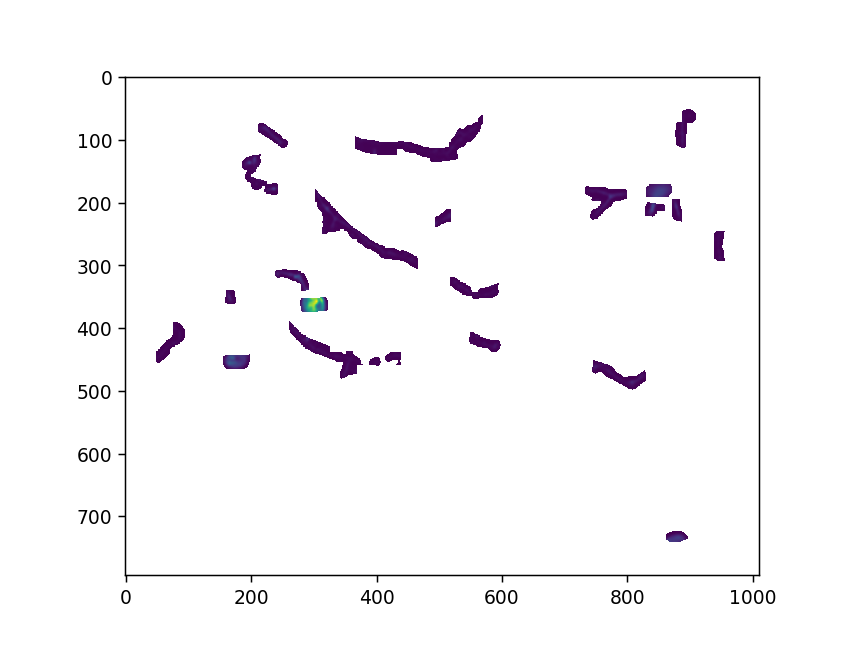

In [172]:
fig,ax=plt.subplots()

ax.imshow(meanIM[0])

<IPython.core.display.Javascript object>


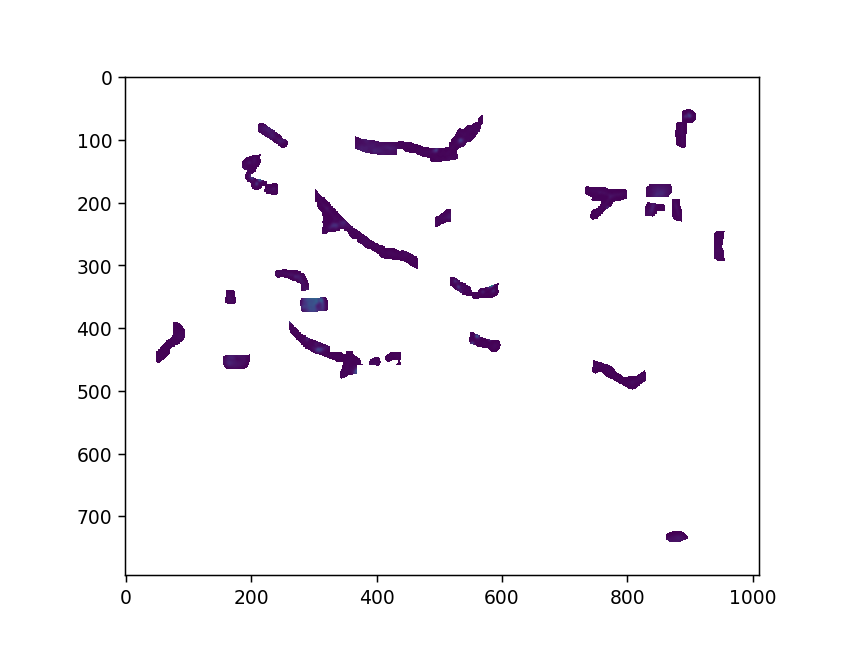

In [173]:
fig,ax=plt.subplots()

ax.imshow(meanIM[1])

In [215]:
trace = gs.get_user_roi_traces(dmd=2,trial=3)
trace = trace.transpose(1,2,0)

<IPython.core.display.Javascript object>


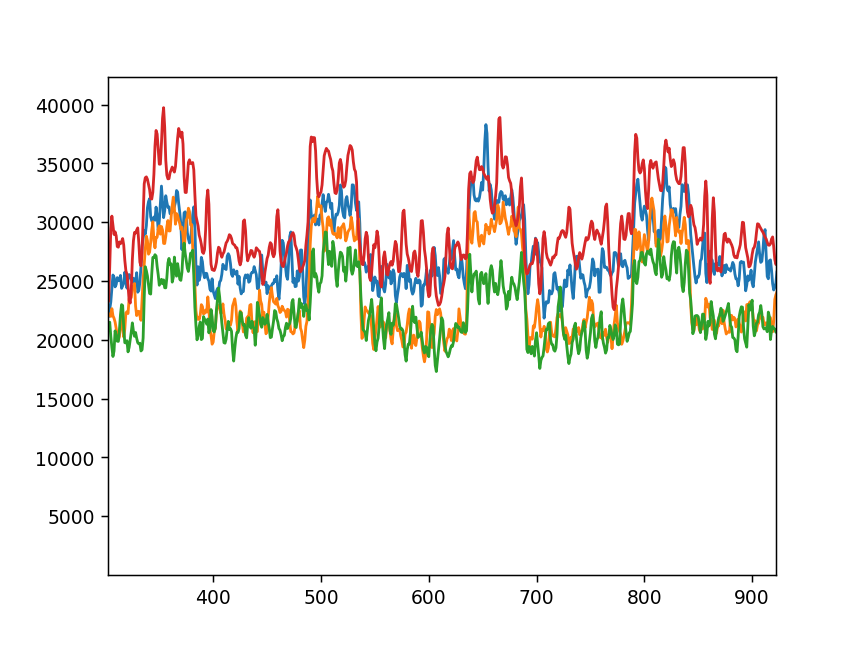

In [219]:
fig,ax=plt.subplots()

for soma in trace:
    ax.plot(soma[1])